In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def readFile(sheet_id, tab_gid):
    """
    Read the CSV file and return a DataFrame.
    """
    full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
    df = pd.read_csv(full_url, skiprows=2)
    return df


/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_1664/2606685944.py:17: FutureWarning: The provided callable <function mean at 0x11318a8b0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = df_long.pivot_table(


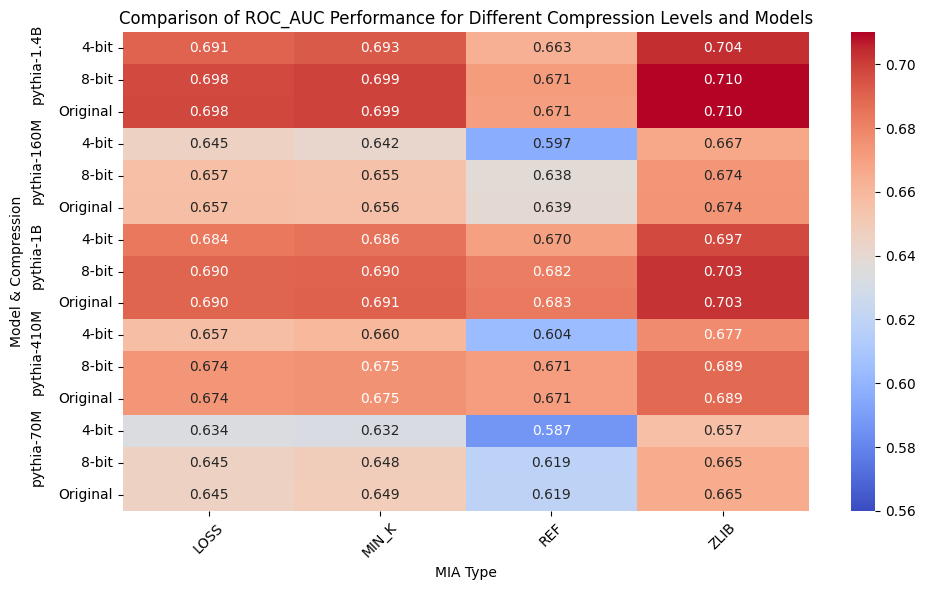

In [3]:

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "298086797"
df = readFile(sheet_id, tab_gid)
df
# === Prepare the data ===
roc_auc_columns = ['LOSS', 'MIN_K', 'ZLIB', 'REF']
df_roc_auc = df[['Model', 'Compression', 'Size (MB)'] + roc_auc_columns]

df_long = df_roc_auc.melt(
    id_vars=['Model', 'Compression', 'Size (MB)'],
    value_vars=roc_auc_columns,
    var_name='ROC_AUC Type',
    value_name='ROC_AUC'
)

pivot_df = df_long.pivot_table(
    values='ROC_AUC',
    index=['Model', 'Compression'],
    columns='ROC_AUC Type',
    aggfunc=np.mean
)

# === Plotting with custom group labels ===
fig, ax = plt.subplots(figsize=(10, 6))

# Heatmap
sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.3f', 
    cbar=True, 
    vmin=0.56, vmax=0.71,
    ax=ax
)

# Hide y-axis label
ax.set_ylabel("")

# Customize y-tick labels to show only compression
compression_labels = [comp for _, comp in pivot_df.index]
ax.set_yticklabels(compression_labels, rotation=0)

# === Add model labels manually for each block ===
models = pivot_df.index.get_level_values(0)
unique_models = models.unique()

# Count how many rows per model
row_counts = models.value_counts().sort_index()
start_idx = 0
for model in unique_models:
    count = row_counts[model]
    center_row = start_idx + count / 2 - 0.5  # Center of the block
    ax.text(
        -0.5, center_row, model, 
        rotation=90, va='center', ha='center',
        fontsize=10, color='black'
    )
    start_idx += count

# Final formatting
ax.set_title("Comparison of ROC_AUC Performance for Different Compression Levels and Models")
ax.set_xlabel("MIA Type")
plt.xticks(rotation=45)
plt.ylabel("Model & Compression", labelpad=25)

plt.tight_layout()
plt.savefig("./output/roc_auc_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_1664/423397433.py:17: FutureWarning: The provided callable <function mean at 0x11318a8b0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_df = df_long.pivot_table(


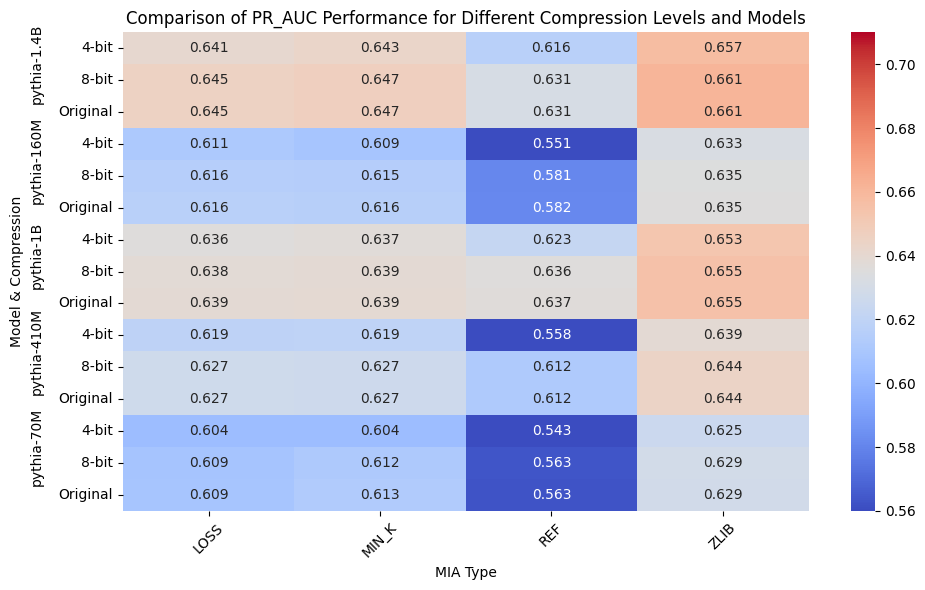

In [4]:
# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1930439748"
df = readFile(sheet_id, tab_gid)
df
# === Prepare the data ===
roc_auc_columns = ['LOSS', 'MIN_K', 'ZLIB', 'REF']
df_roc_auc = df[['Model', 'Compression', 'Size (MB)'] + roc_auc_columns]

df_long = df_roc_auc.melt(
    id_vars=['Model', 'Compression', 'Size (MB)'],
    value_vars=roc_auc_columns,
    var_name='ROC_AUC Type',
    value_name='ROC_AUC'
)

pivot_df = df_long.pivot_table(
    values='ROC_AUC',
    index=['Model', 'Compression'],
    columns='ROC_AUC Type',
    aggfunc=np.mean
)

# === Plotting with custom group labels ===
fig, ax = plt.subplots(figsize=(10, 6))

# Heatmap
sns.heatmap(
    pivot_df, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.3f', 
    cbar=True, 
    vmin=0.56, vmax=0.71,
    ax=ax
)

# Hide y-axis label
ax.set_ylabel("")

# Customize y-tick labels to show only compression
compression_labels = [comp for _, comp in pivot_df.index]
ax.set_yticklabels(compression_labels, rotation=0)

# === Add model labels manually for each block ===
models = pivot_df.index.get_level_values(0)
unique_models = models.unique()

# Count how many rows per model
row_counts = models.value_counts().sort_index()
start_idx = 0
for model in unique_models:
    count = row_counts[model]
    center_row = start_idx + count / 2 - 0.5  # Center of the block
    ax.text(
        -0.5, center_row, model, 
        rotation=90, va='center', ha='center',
        fontsize=10, color='black'
    )
    start_idx += count

# Final formatting
ax.set_title("Comparison of PR_AUC Performance for Different Compression Levels and Models")
ax.set_xlabel("MIA Type")
plt.xticks(rotation=45)
plt.ylabel("Model & Compression", labelpad=25)

plt.tight_layout()
plt.savefig("./output/pr_auc_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# stacked bar chart

In [5]:
# import matplotlib.pyplot as plt

# # Prepare data for a stacked bar plot
# df_long = df_roc_auc.melt(id_vars=['Model', 'Compression'], 
#                           value_vars=roc_auc_columns, 
#                           var_name='ROC_AUC Type', 
#                           value_name='ROC_AUC')

# # Pivot to get model and compression as index and ROC_AUC types as columns
# pivot_df = df_long.pivot_table(values='ROC_AUC', 
#                                index=['Model', 'Compression'], 
#                                columns='ROC_AUC Type', 
#                                aggfunc=np.mean)

# # Plot the stacked bar chart
# pivot_df.plot(kind='bar', stacked=True, figsize=(14, 8), cmap='Set2', width=0.8)

# plt.title("Stacked Bar Plot for ROC_AUC Performance Across Compression Levels and Models")
# plt.xlabel("Model and Compression Type")
# plt.ylabel("Average ROC_AUC")
# plt.xticks(rotation=45)
# plt.legend(title="ROC_AUC Type", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()